# Airbnb Analysis & Visualization with Python

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step:1 Data Collection

In [104]:
df=pd.read_csv('Airbnb_dataset.csv.gz')


C:\Users\Basav\AppData\Local\Temp\ipykernel_21668\2228089163.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Airbnb_dataset.csv.gz')


In [105]:
df

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,$169,1.0,0.0,NaN,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,$167,1.0,1.0,7/6/2015,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,$198,3.0,0.0,NaN,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,$109,2.0,5.0,10/11/2015,0.10,3.0,1.0,386.0,NaN,NaN


In [106]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [107]:
df.shape

(102599, 26)

# Step:2 Data Cleaning

Data Cleaning Tasks

# Checking Missing Values

In [108]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

# Handling Missing values

In [110]:
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

In [111]:
df.fillna({ 'reviews per month': 0, 'last review': df['last review'].min() }, inplace=True)

In [113]:
df.dropna(subset=['NAME', 'host name', 'host_identity_verified',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews','review rate number', 'calculated host listings count',
       'availability 365'], inplace=True)

In [116]:
df.drop(columns=['license','house_rules'], errors='ignore',inplace=True)

In [114]:
# Removing dolor sign and converting price to float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Basav\AppData\Local\Temp\ipykernel_21668\3331109855.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\Basav\AppData\Local\Temp\ipykernel_21668\3331109855.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


In [117]:
df.isnull().sum()

id                                0
NAME                              0
host id                           0
host_identity_verified            0
host name                         0
neighbourhood group               0
neighbourhood                     0
lat                               0
long                              0
country                           0
country code                      0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price                             0
service fee                       0
minimum nights                    0
number of reviews                 0
last review                       0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
dtype: int64

In [118]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,2013.0,577.0,115.0,3.0,74.0,2019-06-22,0.59,3.0,1.0,374.0
7,1005202,BlissArtsSpace!,90821839709,unconfirmed,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,2009.0,1060.0,212.0,45.0,49.0,2017-10-05,0.40,5.0,1.0,219.0


# Removing Duplicate Values

In [120]:
df.drop_duplicates(inplace=True)

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98509 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              98509 non-null  int64         
 1   NAME                            98509 non-null  object        
 2   host id                         98509 non-null  int64         
 3   host_identity_verified          98509 non-null  object        
 4   host name                       98509 non-null  object        
 5   neighbourhood group             98509 non-null  object        
 6   neighbourhood                   98509 non-null  object        
 7   lat                             98509 non-null  float64       
 8   long                            98509 non-null  float64       
 9   country                         98509 non-null  object        
 10  country code                    98509 non-null  object        
 11  instan

# EDA

In [122]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,9.850900e+04,9.850900e+04,98509.000000,98509.000000,98509.000000,98509.000000,98509.000000,98509.000000,98509.000000,98509,98509.000000,98509.000000,98509.000000,98509.000000
mean,2.927555e+07,4.925024e+10,40.728036,-73.949629,2012.488138,625.530205,125.106843,8.046402,27.341644,2018-05-18 06:02:48.179557120,1.166535,3.278665,7.973241,140.883168
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.517556e+07,2.455589e+10,40.688720,-73.982570,2008.000000,340.000000,68.000000,2.000000,1.000000,2017-08-03 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.932383e+07,4.911063e+10,40.722250,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-05-22 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.333016e+07,7.398748e+10,40.762740,-73.932270,2017.000000,913.000000,183.000000,5.000000,30.000000,2019-07-01 00:00:00,1.720000,4.000000,2.000000,268.000000
max,5.735803e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.622021e+07,2.854665e+10,0.055831,0.049545,5.761132,331.739043,66.351092,28.434029,49.216253,NaN,1.685965,1.285089,32.453375,135.397230


In [123]:
cm = df.corr(numeric_only=True)

<Axes: >

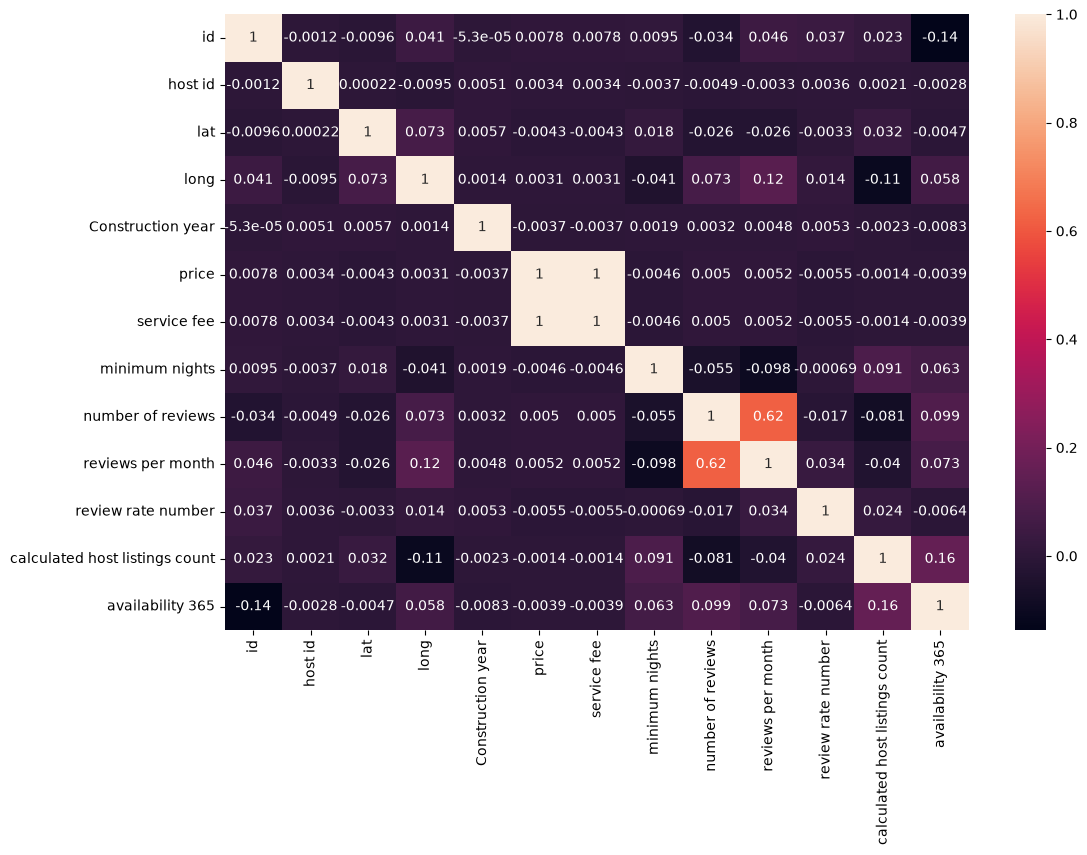

In [125]:
plt.figure(figsize=(12, 8))
sns.heatmap(cm,annot=True)


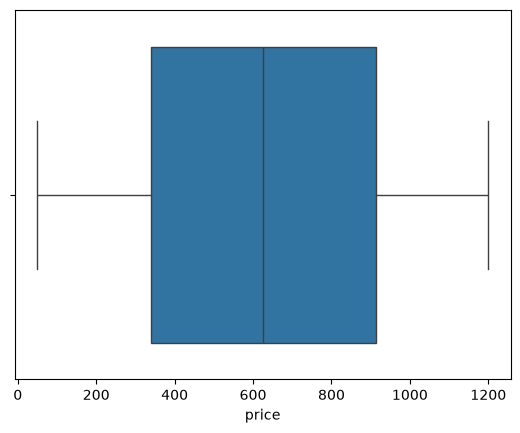

In [126]:
sns.boxplot(x=df['price'])
plt.show()

# Visualization

# What is the distribution of listing prices?

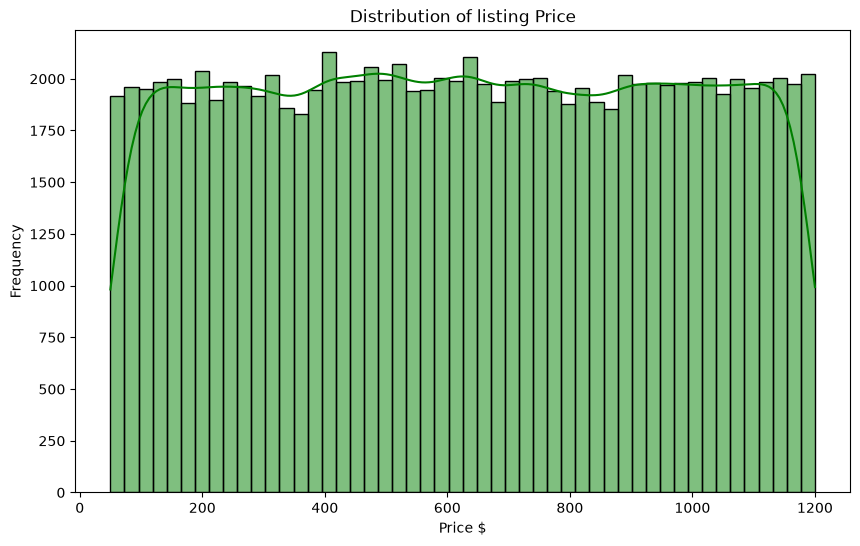

In [130]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'],bins=50,kde=True,color='green')
plt.title('Distribution of listing Price')
plt.xlabel('Price $')
plt.ylabel('Frequency')
plt.show()

# How are different Room types distributed?

In [131]:
df['room type']

0            Private room
1         Entire home/apt
4         Entire home/apt
5         Entire home/apt
7            Private room
               ...       
102029       Private room
102030       Private room
102031       Private room
102032       Private room
102040       Private room
Name: room type, Length: 98509, dtype: object

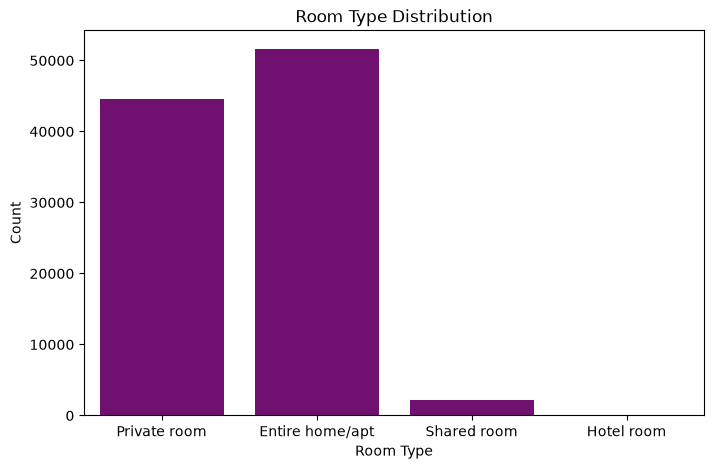

In [153]:
plt.figure(figsize=(8,5))
sns.countplot(x="room type",data = df, color="purple")
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

# How are listing distributed across different nighborhoods?

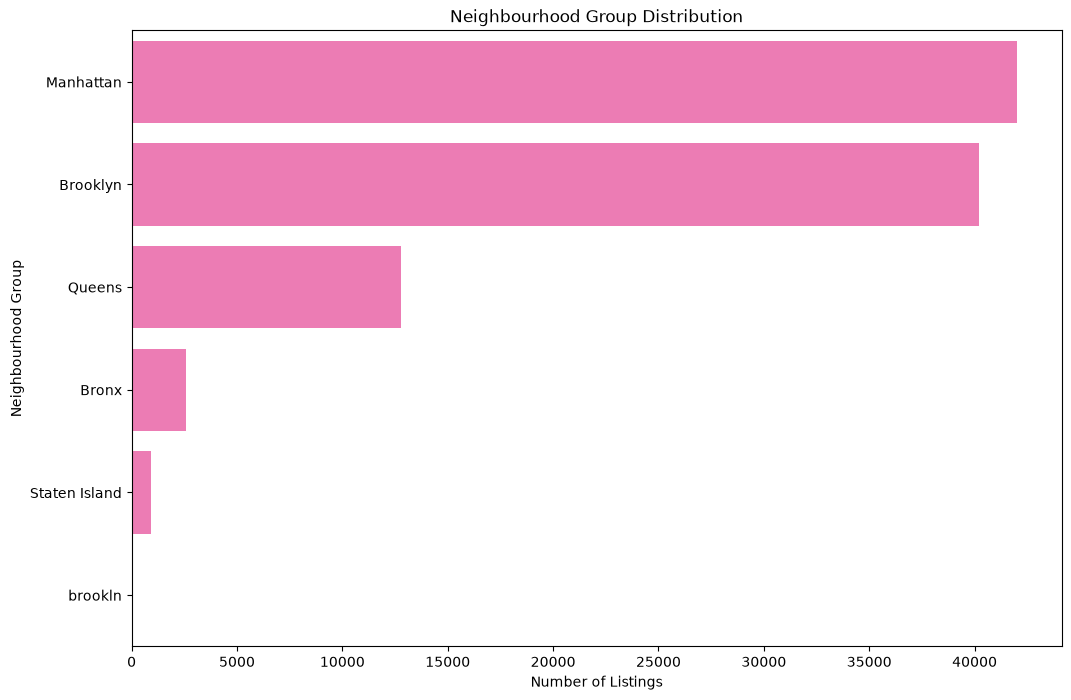

In [150]:
plt.figure(figsize=(12, 8))

sns.countplot(
    y="neighbourhood group",
    data=df,color='hotpink',
    order=df['neighbourhood group'].value_counts().index
)

plt.title('Neighbourhood Group Distribution')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood Group')

plt.show()

# What is the relationship between Price and room type?


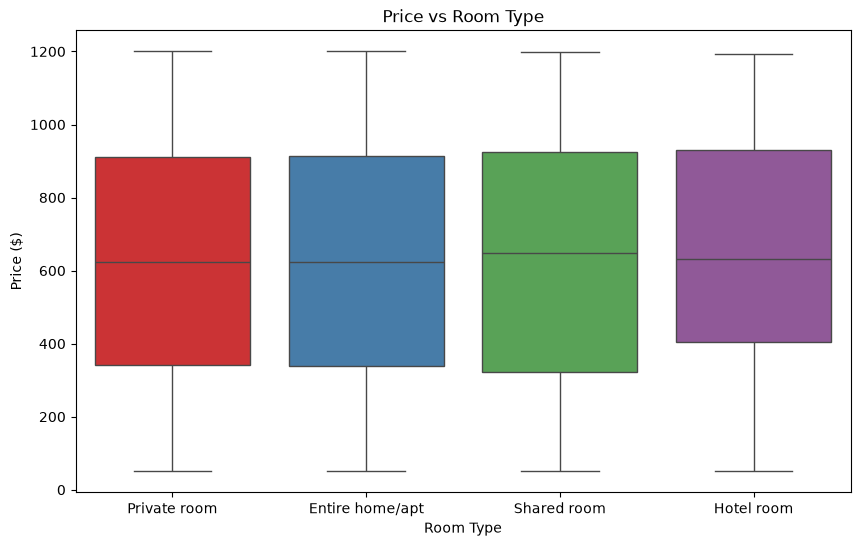

In [159]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='room type',
    y='price',
    hue='room type',
    data=df,
    palette='Set1',
    legend=False
)

plt.title('Price vs Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')

plt.show()

# How has the number of reviews change over with time

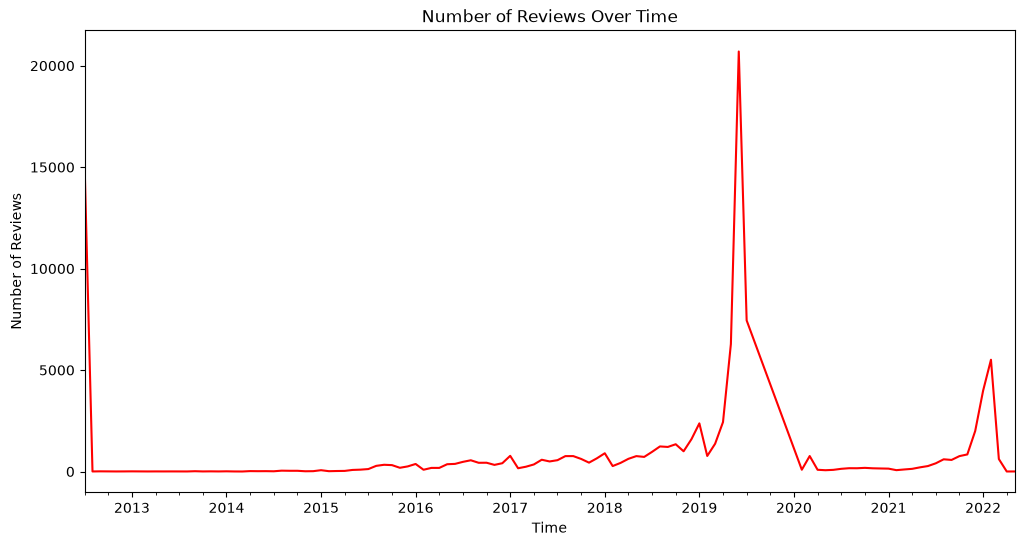

In [161]:
df['last review']= pd. to_datetime(df['last review'])
reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
reviews_over_time.plot(kind='line', color='red')
plt.title('Number of Reviews Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Reviews')
plt.show()